# Get stock data for a single company


DataReader offers the data source 'iex'. To experiment with the data outside DataCamp environment, you will need an IEX Cloud account.

IEX limits access to stock price series to the last five years.

Retrieving stock price data from IEX is simple after importing the DataReader package and using the start and/or end arguments in form date(YYYY, MM, DD):

`stock_data = DataReader(ticker, data_source, start, end)`


In [11]:
# Import DataReader
from pandas_datareader.data import DataReader

# Import date
from datetime import date

# # Set start and end dates
# start = date(2016,1,1)
# end = date(2016,12,31)

# # Set the ticker
# ticker = 'AAPL'

# # Set the data source
# data_source = 'yahoo'

# # Import the stock prices
# stock_prices = DataReader( ticker,data_source=data_source, start=start, end=end)

# # Display and inspect the result
# print(stock_prices.head())
# stock_prices.info()

# Visualize a stock price trend


The most important change to the functionality is the limitation of the data to the last five years. The DataFrame returned by the DataReader has the same columns, but in lower case.

The matplotlib.pyplot package is essential to visualizing stock price trends in Python.


In [2]:
# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# # Set start and end dates
# start = date(2016,1,1)
# end = date(2016,12,31)

# # Set the ticker and data_source
# ticker = 'FB'
# data_source = 'iex'

# # Import the data using DataReader
# stock_prices = DataReader(ticker, data_source=data_source, start=start, end= end)

# # Plot close
# stock_prices["close"].plot(title = ticker)

# # Show the plot
# plt.show()

# Visualize the long-term oil price trend


you learned how to retrieve data from the Federal Reserve Economic Data (FRED) portal.

Here, you will use this new data source to visualize the oil price trend over the last 50 years, specifically, the Spot Crude Oil Price: West Texas Intermediate (WTI).


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 680 entries, 1968-01-01 to 2024-08-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   WTISPLC  680 non-null    float64
dtypes: float64(1)
memory usage: 10.6 KB


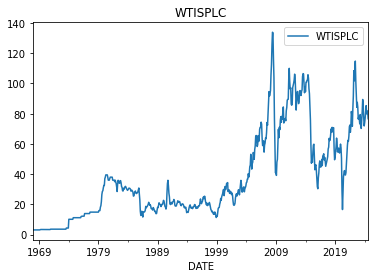

In [5]:
# Set start date
start = date(1968,1,1)

# Set series code
series = 'WTISPLC'

# Import the data
oil_price = DataReader(series, data_source='fred', start=start)

# Inspect the price of oil
oil_price.info()

# Plot the price of oil
oil_price.plot(title = series)

# Show the plot
plt.show()

# Compare labor market participation and unemployment rates


Two economic data series in FRED are the Civilian Unemployment Rate ('UNRATE') and the Civilian Labor Force Participation Rate ('CIVPART').

These rates highlight two important aspects of the US labor market: the share of the civilian population that is currently unemployed or seeking employment, and the share of those active in the labor market that are in fact employed.

This means that the numbers indicate both the size of the labor market relative to the total population, as well as the size of unemployment relative to the labor market.


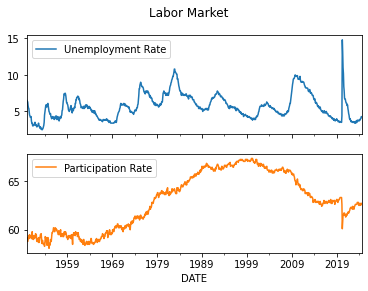

In [6]:
# Set the start date
start = date(1950,1,1)

# Define the series codes
series = ['UNRATE', 'CIVPART']

# Import the data
econ_data = DataReader(series, data_source='fred', start=start)

# Assign new column labels
econ_data.columns = ['Unemployment Rate', 'Participation Rate']

# Plot econ_data
econ_data.plot(title='Labor Market',subplots=True)

# Show the plot
plt.show()

# Compare bond and stock performance


Bonds and stocks are the most important investment alternatives. Now that you can import data from both the Federal Reserve and Yahoo! Finance, you can compare the performance of both asset classes. You'll be using a Total Return Index for each class, which accounts for returns due to both price increases and payments like interest or dividends.

For bonds, you'll use the Bank of America Merrill Lynch US High Yield Total Return Index Value ('BAMLHYH0A0HYM2TRIV'). For stocks, you'll use the S&P 500 Index ('SP500'). Both are available for the past 10 years from the Federal Reserve's FRED service.


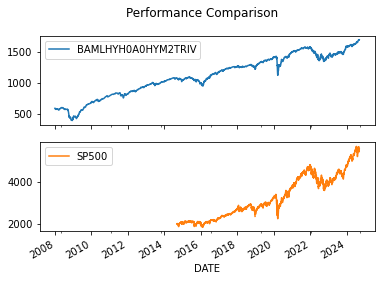

In [7]:
# Set the start date
start = date(2008,1,1)

# Set the series codes
series = ['BAMLHYH0A0HYM2TRIV', 'SP500']

# Import the data
data = DataReader(series, data_source="fred", start=start)

# Plot the results
data.plot(title = 'Performance Comparison', subplots = True)

# Show the plot
plt.show()

# Select the top 5 listed consumer companies


As you have just learned, it is possible to filter stocks based on criteria with the sort_values() method and an argument that specifies the column to filter by. Additionally, you can include the argument ascending=False to sort entries from highest to lowest.

Here, you will use this function to find out the five most valuable companies in the Consumer Services sector. This is measured with market capitalization, or the combined value of all shares in a company. pandas has been imported as pd, as has the listings DataFrame from the first chapter. As a refresher, it contains data from the AMEX, NYSE, and NASDAQ.


In [14]:
import pandas as pd
xls = pd.ExcelFile('dataset/listings.xlsx')

# Extract the sheet names from xls
exchanges = xls.sheet_names

# Create an empty list: listings
listings=[]

# Import the data
for exchange in exchanges:
    listing = pd.read_excel(xls, sheet_name=exchange, na_values='n/a')
    listing['Exchange'] = exchange
    listings.append(listing)

# Concatenate the listings: listing_data
listing_data = pd.concat(listings)

# Inspect the results
listing_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6674 entries, 0 to 3146
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Stock Symbol           6674 non-null   object 
 1   Company Name           6674 non-null   object 
 2   Last Sale              6590 non-null   float64
 3   Market Capitalization  6674 non-null   float64
 4   IPO Year               2852 non-null   float64
 5   Sector                 5182 non-null   object 
 6   Industry               5182 non-null   object 
 7   Exchange               6674 non-null   object 
dtypes: float64(3), object(5)
memory usage: 469.3+ KB


In [15]:
listings = listing_data

# Select companies in Consumer Services
consumer_services = listings[listings.Sector == 'Consumer Services']

# Sort consumer_services by market cap
consumer_services2 = consumer_services.sort_values('Market Capitalization', ascending=False)

# Display first 5 rows of designated columns
print(consumer_services2[['Company Name', 'Exchange', 'Market Capitalization']].head())

                   Company Name Exchange  Market Capitalization
4              Amazon.com, Inc.   nasdaq           4.221385e+11
3013      Wal-Mart Stores, Inc.     nyse           2.218646e+11
3014  Walt Disney Company (The)     nyse           1.789973e+11
6           Comcast Corporation   nasdaq           1.764745e+11
1438     Home Depot, Inc. (The)     nyse           1.752626e+11


# Get the ticker of the largest consumer services company


Instead of indexing your data with a conditional expression, you can also filter by certain values with .loc[row_selector, column_selector]. Additionally, you can use .set_index() to set a particular column with unique values as the index of a DataFrame, and .idxmax() to return the index of the maximum value.


In [17]:
# # Set the index of listings to Stock Symbol
# listings_ss = listings.set_index("Stock Symbol")

# # Get ticker of the largest Consumer Services company
# ticker = listings_ss.loc[listings_ss.Sector == 'Consumer Services', 'Market Capitalization'].idxmax()

# # Set the start date
# start = date(2015,1,1)

# # Import the stock data
# data = DataReader(ticker, data_source="yahoo", start=start)

# # Plot close and volume
# data[['close', 'volume']].plot(secondary_y="volume", title=ticker)

# # Show the plot
# plt.show()

# Get the largest consumer company listed after 1998


You can filter your data by even more conditions by enclosing each condition in parentheses and using logical operators like & and |.

Here, you will find out which company is the largest consumer services company that went public after Amazon did in 1997. The data is contained in the column 'IPO Year'; an Initial Public Offering (IPO) is a financial term that describes the first time that the stock of a private company is offered to the public.


In [21]:
# # Set Stock Symbol as the index
# listings = listings.set_index('Stock Symbol')

# # Get ticker of the largest consumer services company listed after 1997
# ticker = listings.loc[(listings.Sector == 'Consumer Services') & (listings["IPO Year"] > 1998), 'Market Capitalization'].idxmax()

# # Set the start date
# start = date(2015,1,1)

# # Import the stock data
# data = DataReader(ticker, data_source="yahoo", start=start)

# # Plot close and volume
# data[['close', 'volume']].plot(secondary_y='volume', title=ticker)

# # Show the plot
# plt.show()

# Get data for the 3 largest financial companies


A pd.MultiIndex() object has more than one identifier per row. This allows you to get the data based on criteria for multiple companies at once.

Let's apply this new skill to get the stock prices for the largest companies in the financial sector


In [23]:
# # Set Stock Symbol as the index
# listings_ss = listings.set_index('Stock Symbol')

# # Get ticker of 3 largest finance companies
# top_3_companies = listings_ss.loc[listings_ss.Sector == 'Finance','Market Capitalization'].nlargest(n=3)

# # Convert index to list
# top_3_tickers = top_3_companies.index.to_list()

# # Set start date
# start = date(2015,1,1)

# # Set end date
# end = date(2020,4,1)

# # Import stock data
# result = DataReader(top_3_tickers, data_source="iex", start=start, end = end)

# # Apply stack method 
# data = result.stack()

# # Unstack and inspect result
# data['close'].unstack().info()